**Modified from the original Genentech/decima-applications source** by the DanioDecima authors (Chan Zuckerberg Biohub) on 2026-05-10. See `daniodecima-applications-main/FORK_NOTES.md` for the scope of modifications. Original copyright Genentech, Inc., 2024 (Genentech Non-Commercial Software License v1.0).

# Evaluate Decima's performance on held-out genes

In [2]:
import anndata
import os
from plotnine import *
%matplotlib inline

## Paths

In [20]:
#save_dir="/gstore/data/resbioai/grelu/decima/20240823"
save_dir="/hpc/mydata/mathias.voges/Projects/research/zf-decima/outputs/grelu/decima"
matrix_file = os.path.join(save_dir, "data_out_zf-Decima_Random_Rep0.h5ad")
_h5_file = os.path.join(save_dir, "data.h5")

## Load data

In [21]:
ad = anndata.read_h5ad(matrix_file)

In [22]:
print(ad)

AnnData object with n_obs × n_vars = 94 × 31767
    obs: 'timepoint', 'cell_type', 'n_cells', 'tissue', 'organ', 'frac_nan', 'total_counts', 'n_genes', 'size_factor', 'test_pearson', 'train_pearson', 'val_pearson'
    var: 'index', 'chrom', 'start', 'end', 'strand', 'gene_type', 'frac_nan', 'mean_counts', 'n_tracks', 'gene_start', 'gene_end', 'gene_length', 'gene_mask_start', 'gene_mask_end', 'frac_N', 'Upstream bases', 'Downstream bases', 'gene', 'fold', 'dataset', 'pearson', 'size_factor_pearson'
    uns: 'log1p'
    layers: 'counts', 'norm', 'preds', 'scaled'

In [23]:
for dataset in ad.var.dataset.unique():
    print(dataset)
    print(ad.var.loc[ad.var.dataset==dataset, 'pearson'].mean().round(2))
    print(ad.var.loc[ad.var.dataset==dataset, 'size_factor_pearson'].mean().round(2))
    print(ad.obs[f"{dataset}_pearson"].mean().round(2))

test
0.22
0.18
0.44
train
0.24
0.19
0.46
val
0.24
0.19
0.46


## Plot correlations on test genes

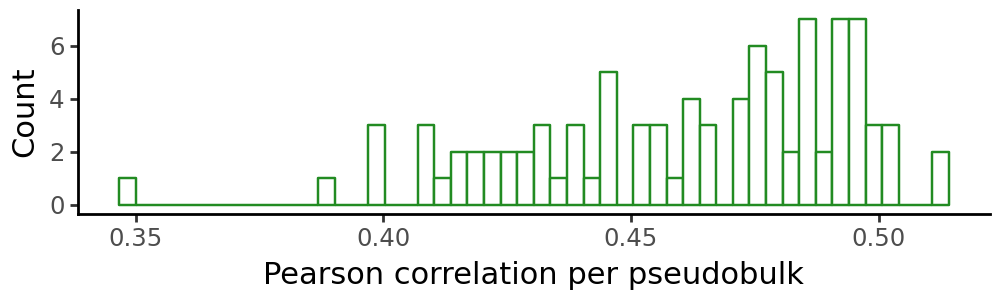

In [24]:
(
    ggplot(ad.obs, aes(x="val_pearson"))
    + geom_histogram(fill="white", color="forestgreen", bins=50)
    + theme_classic() + theme(figure_size=(5,1.5))
    + xlab("Pearson correlation per pseudobulk")
    + ylab("Count")
)

/hpc/mydata/mathias.voges/anaconda/latest/x86_64/envs/pytorch/lib/python3.12/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_bin : Removed 389 rows containing non-finite values.


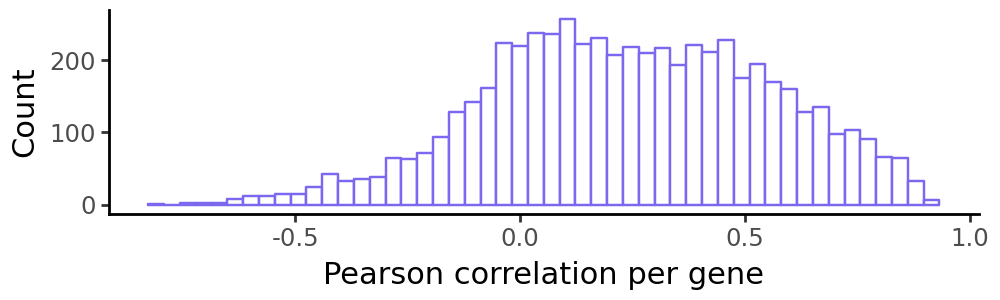

In [25]:
(
    ggplot(ad.var[ad.var.dataset=="val"], aes(x="pearson"))
    + geom_histogram(fill="white", color="mediumslateblue", bins=50)
    + theme_classic() + theme(figure_size=(5,1.5))
    + xlab("Pearson correlation per gene")
    + ylab("Count")
)